In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import keras
from keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Conv2D, MaxPooling2D, Input, Conv2DTranspose, Concatenate, BatchNormalization, UpSampling2D
from keras.layers import  Dropout, Activation, concatenate, Cropping2D, SpatialDropout2D
from keras.optimizers import Adam, SGD, RMSprop
from keras.layers import ELU, PReLU, LeakyReLU
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall
from keras import backend as K
from keras.utils import plot_model
import tensorflow as tf
import glob
import random
import cv2
from random import shuffle
from tensorflow.keras import backend as K
import math
from keras import regularizers
from datetime import datetime
import types
import os, random

# --- compat Keras 2.10: expõe keras.saving.register_keras_serializable ---
if not hasattr(keras, "saving"):
    keras.saving = types.SimpleNamespace()
if not hasattr(keras.saving, "register_keras_serializable"):
    keras.saving.register_keras_serializable = tf.keras.utils.register_keras_serializable

#SEED fixa - reprodutibilidade
#SEED = 42
#SEED = 123
SEED = 2024
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

In [2]:
print("GPUs disponíveis:", tf.config.list_physical_devices('GPU'))

GPUs disponíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# VARIAVEIS GERAIS

img_sz_x = 256
img_sz_y = 256

batch_size = 16

entrada = "datasets"
#entrada = "saida"

#dataset = "crop_OralEpitheliumDB"
dataset = "crop_OralEpitheliumDB_aug"

protoseg_online = False

In [4]:
class ProtoSeg(tf.keras.Model):
    def __init__(self,ndims='2d'):
        super().__init__()

        # for 1D: self.dims=(2)
        # for 2D image: self.dims=(2,3)
        # for 3D image: self.dims=(2,3,4)
        if ndims == '1d':
            self.dims = (2)
        elif ndims == '2d':
            self.dims = (2,3)
        elif ndims == '3d':
            self.dims = (2,3,4)
        else:
            raise ValueError('ndims must be in [1d,2d,3d]')

        #self.softmax = nn.Softmax(dim=1)

    def softmax(self, x):
        return tf.nn.softmax(x)

    def call(self,xfeat,pred,mask=None):
        #@ xfeat: the deep feature need to be inperpreted
        #@ pred: the initial segmentation results from the last layer of the network
        #@ mask is to maks out the background of the image (without any tissue)

        if mask is not None:
            pos_prototype = tf.reduce_sum(xfeat*pred*mask,dim=self.dims,keepdim=True)
            num_prototype = tf.reduce_sum(pred*mask,dim=self.dims,keepdim=True)
            pos_prototype = pos_prototype / num_prototype

            rpred = 1 - pred

            neg_prototype = tf.reduce_sum(xfeat*rpred*mask,dim=self.dims,keepdim=True)
            num_prototype = tf.reduce_sum(rpred*mask,dim=self.dims,keepdim=True)
            neg_prototype = neg_prototype / num_prototype

            pfeat = -tf.reduce_sum((xfeat - pos_prototype)**2, axis=1, keepdims=True)
            nfeat = -tf.reduce_sum((xfeat - neg_prototype)**2, axis=1, keepdims=True)

            disfeat = tf.concat([nfeat, pfeat], axis=1)
            pred = self.softmax(disfeat)

        else:
            xfeat = tf.cast(xfeat, tf.float32)
            pred = tf.cast(pred, tf.float32)

            pos_prototype = tf.reduce_sum(xfeat*pred)
            num_prototype = tf.reduce_sum(pred)
            pos_prototype = pos_prototype / num_prototype

            rpred = 1 - pred
            rpred = tf.cast(rpred, tf.float32)

            neg_prototype = tf.reduce_sum(xfeat*rpred)
            num_prototype = tf.reduce_sum(rpred)
            neg_prototype = neg_prototype / num_prototype

            pfeat = -tf.reduce_sum((xfeat - pos_prototype)**2, axis=1, keepdims=True)
            nfeat = -tf.reduce_sum((xfeat - neg_prototype)**2, axis=1, keepdims=True)

            disfeat = tf.concat([nfeat,pfeat], axis=1)
            pred = self.softmax(disfeat)

        return pred

In [5]:
from random import shuffle
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from PIL import Image
import cv2

current_X = {}
current_Y = {}

def image_generator(group, files, batch_size = 4, sz = (img_sz_x, img_sz_y), mendeley=False):
    global current_X, current_Y

    while True:
        #extract a random batch
        batch = np.random.choice(files, size = batch_size)

        #variables for collecting batches of inputs and outputs
        batch_x = []
        batch_y = []

        for f in batch:

            #get the masks. Note that masks are png files
            mask = Image.open(f'{entrada}/{dataset}/{group}/mascaras/{f}.png')
            mask = np.array(mask.resize(sz))
            mask = np.expand_dims(mask, axis=-1)

            #preprocess the mask
            mask[mask > 0] = 1
            batch_y.append(mask)

            # Carregar a imagem
            raw = Image.open(f'{entrada}/{dataset}/{group}/{f}.png')
            raw = np.array(raw.resize(sz))
            raw = np.array(raw)

            #check the number of channels because some of the images are RGBA or GRAY
            if len(raw.shape) == 2:
              raw = np.stack((raw,)*3, axis=-1)

            raw = raw[:, :, 0:3]

            batch_x.append(raw)

        #preprocess a batch of images and masks
        batch_x = np.array(batch_x)/255.
        batch_y = np.array(batch_y)
        #batch_y = np.expand_dims(batch_y,3)

        if group == "train":
          current_X = batch_x[0]
          current_Y = batch_y[0]

        yield (batch_x, batch_y)

In [6]:
import os

train_files = list(os.path.splitext(file)[0] for file in os.listdir(f'{entrada}/{dataset}/train') if os.path.isfile(os.path.join(f'{entrada}/{dataset}/train', file)))
val_files = list(os.path.splitext(file)[0] for file in os.listdir(f'{entrada}/{dataset}/val') if os.path.isfile(os.path.join(f'{entrada}/{dataset}/val', file)))
test_files = list(os.path.splitext(file)[0] for file in os.listdir(f'{entrada}/{dataset}/test') if os.path.isfile(os.path.join(f'{entrada}/{dataset}/test', file)))

print("TOTAL IMAGENS:", len(train_files) + len(val_files) + len(test_files))
print("SPLIT TREINO:", len(train_files))
print("SPLIT VALIDACAO:", len(val_files))
print("SPLIT TESTE:", len(test_files))


train_generator = image_generator("train", train_files, batch_size = batch_size)
val_generator  = image_generator("val", val_files, batch_size = math.floor(batch_size))
test_generator  = image_generator("test", test_files, batch_size = math.floor(len(test_files)/4))

TOTAL IMAGENS: 2826
SPLIT TREINO: 2552
SPLIT VALIDACAO: 90
SPLIT TESTE: 184


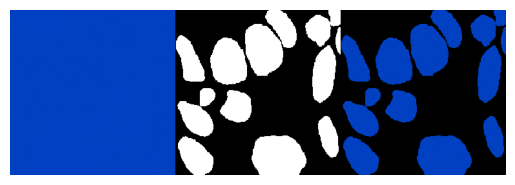

In [7]:
x, y= next(train_generator)

plt.axis('off')

img = x[0]
msk = y[0].squeeze()
msk = np.stack((msk,)*3, axis=-1)

plt.imshow( np.concatenate([img, msk, img*msk], axis = 1))

In [8]:
@tf.function
@keras.saving.register_keras_serializable()
def mean_iou(y_true, y_pred):
    yt0 = tf.cast(y_true[:,:,:,0], tf.float32)  # Converter para float32
    yp0 = tf.cast(y_pred[:,:,:,0] > 0.5, tf.float32)  # Já está como float32
    inter = tf.math.count_nonzero(tf.logical_and(tf.equal(yt0, 1), tf.equal(yp0, 1)))
    union = tf.math.count_nonzero(tf.add(yt0, yp0))  # Ambos agora são float32
    iou = tf.where(tf.equal(union, 0), 1.0, tf.cast(inter / union, tf.float32))
    return iou

In [9]:
# DROPOUT ESPACIAL

def unet(sz = (img_sz_x, img_sz_y, 3), learning_rate=0.001):
  inputs = Input(sz)

  # Definindo a regularização L2
  l2_reg = 0.001

  # Encoder (Downsampling)
  conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
  conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
  pool1 = MaxPooling2D((2, 2))(conv1)

  conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
  conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
  drop2 = SpatialDropout2D(0.50)(conv2)
  pool2 = MaxPooling2D((2, 2))(drop2)

  conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
  conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
  drop3 = SpatialDropout2D(0.50)(conv3)
  pool3 = MaxPooling2D((2, 2))(drop3)

  conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
  conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)
  drop4 = SpatialDropout2D(0.50)(conv4)
  pool4 = MaxPooling2D((2, 2))(drop4)

  # Bottleneck
  conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool4)
  conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv5)
  drop5 = SpatialDropout2D(0.50)(conv5)

  # Decoder (Upsampling)
  up6 = Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(drop5)
  merge6 = concatenate([up6, drop4], axis=3)
  conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(merge6)
  conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv6)

  up7 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv6)
  merge7 = concatenate([up7, drop3], axis=3)
  conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(merge7)
  conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv7)

  up8 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv7)
  merge8 = concatenate([up8, drop2], axis=3)
  conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(merge8)
  conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv8)

  up9 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv8)
  merge9 = concatenate([up9], axis=3)
  conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(merge9)
  conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv9)

  # Output Layer
  output = Conv2D(1, (1, 1), activation='sigmoid')(conv9)  # Sigmoid para segmentação binária

  model = Model(inputs, output)
  return model

In [10]:
@tf.function
def dice_score(mask_true, mask_pred): ### IMPORTANTE: TESTAR TROCAR A METRICA PRA IOU E ACURÁCIA
    mask_true = tf.cast(mask_true, tf.float32)
    mask_pred = tf.cast(mask_pred, tf.float32)
    intersection = tf.reduce_sum(mask_true * mask_pred)
    dice = (2.0 * intersection) / (tf.reduce_sum(mask_true) + tf.reduce_sum(mask_pred))
    return dice

@tf.function
@keras.saving.register_keras_serializable()
def SA_score(y_true, y_pred): # images, masks, outputs, feature_extractor
    with tf.device('/GPU:0'):
      img = current_X
      mask = y_true
      output = current_Y #Assim funciona em treino e teste
      x = tf.reshape(img, (1, 256, 256, 3))
      features = feature_extractor(x)
      x = tf.transpose(features, (0, 3, 1, 2))
      pred_map = tf.transpose(output, (2, 0, 1)) # (256, 256, 1)
      pred_map = tf.reshape(pred_map, (1, 1, 256, 256))
      shape = int(x.shape[2])
      if shape != 256:
          x = tf.image.resize(x, size=(256, 256), method='bilinear')
      probability_map = neters(x, pred_map, mask=None)
      binary_map = tf.argmax(probability_map, 1)
      bmap = tf.transpose(binary_map, (1, 2, 0))
      sa_score = dice_score(mask[0], bmap)
      if tf.reduce_any(tf.math.is_nan(sa_score)):
        sa_score = tf.constant(0, dtype=tf.float32)
      return sa_score

In [11]:
from tensorflow.keras import backend as K

smooth = 1.0

# ---------- BCE (baseline) ----------
def bce_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.keras.losses.binary_crossentropy(y_true, y_pred)

# ---------- COMBO (BCE + Dice) ----------
def combo_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

# ---------- FOCAL (Lin et al., 2017) ----------
def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = K.clip(y_pred, K.epsilon(), 1. - K.epsilon())
    pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
    pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
    return (-K.mean(alpha * K.pow(1. - pt_1, gamma) * K.log(pt_1))
            -K.mean((1 - alpha) * K.pow(pt_0, gamma) * K.log(1. - pt_0)))
    
# ---------- Focal alpha=0.5 (variação) ----------
def focal_loss_alpha05(y_true, y_pred):
    return focal_loss(y_true, y_pred, alpha=0.5)
    
# ---------- DICE ----------
def dice_coef(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

# ---------- TVERSKY (alpha=0.7) ----------
def tversky_index(y_true, y_pred, alpha=0.7):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_pos = K.flatten(y_true)
    y_pred_pos = K.flatten(y_pred)
    true_pos  = K.sum(y_true_pos * y_pred_pos)
    false_neg = K.sum(y_true_pos * (1 - y_pred_pos))
    false_pos = K.sum((1 - y_true_pos) * y_pred_pos)
    return (true_pos + smooth) / (true_pos + alpha*false_neg + (1-alpha)*false_pos + smooth)

def tversky_loss(y_true, y_pred):
    return 1 - tversky_index(y_true, y_pred)

# ---------- FOCAL TVERSKY (gamma=0.75) ----------
def focal_tversky_loss(y_true, y_pred, gamma=0.75):
    ti = tversky_index(y_true, y_pred)
    return K.pow((1 - ti), gamma)


#Extras

    # ---------- TVERSKY + BCE (análoga à Combo) ----------
def tversky_bce_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + tversky_loss(y_true, y_pred)

    # ---------- Combo loss ponderada ----------
def combo_pesada_dice(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32); y_pred = tf.cast(y_pred, tf.float32)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.5 * bce + 1.0 * dice_loss(y_true, y_pred)  # mais peso à região
    
    # ---------- Combo loss ponderada reverso----------
def combo_pesada_bce_reverso(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32); y_pred = tf.cast(y_pred, tf.float32)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 1.0 * bce + 0.5 * dice_loss(y_true, y_pred)

    # ---------- Focal + Dice ----------
def focal_dice_loss(y_true, y_pred):
    return focal_loss(y_true, y_pred) + dice_loss(y_true, y_pred)

In [12]:
# Escolha do experimento: aponte para a função de perda desejada
LOSS_FN = focal_dice_loss

@tf.function
@keras.saving.register_keras_serializable()
def custom_loss(y_true, y_pred):
    base = LOSS_FN(y_true, y_pred)
    sa_score = SA_score(y_true, y_pred)
    return tf.add(base, sa_score)

In [13]:
#lr = 0.001
lr = 0.0001
optimizer = Adam(learning_rate=lr)
model = unet(sz=(256, 256, 3), learning_rate=lr)
if protoseg_online:
  # cria UMA vez os objetos que a SA_score usa (fora de qualquer @tf.function)
  feature_extractor = Model(inputs=model.inputs, outputs=model.layers[-1].output)
  neters = ProtoSeg(ndims='2d')
  model.compile(optimizer = optimizer, loss=custom_loss, metrics = [mean_iou, BinaryAccuracy(), Precision(), Recall()]) # PROTOSEG ONLINE
  modelo = f"Unet_Protoseg_{dataset.replace('/', '_')}"
else:
  model.compile(optimizer = optimizer, loss=LOSS_FN, metrics = [mean_iou, BinaryAccuracy(), Precision(), Recall()]) # SEM PROTOSEG - usa a LOSS_FN pura (sem SA_score)
  modelo = f"Unet_{dataset.replace('/', '_')}"
print(modelo)

Unet_crop_OralEpitheliumDB_aug


In [14]:
# ============ IDENTIFICADOR PADRONIZADO DA RODADA ============

# nome da loss (funciona nos dois modos: online usa LOSS_FN; offline = bce)
if protoseg_online:
    loss_id = LOSS_FN.__name__.replace("_loss", "")   # "bce_loss" -> "bce", "combo_loss" -> "combo"
else:
    loss_id = LOSS_FN.__name__.replace("_loss", "")   # SEM PROTOSEG: usa a mesma LOSS_FN (Dice puro, Tversky puro, etc.)

proto_id = "online" if protoseg_online else "offline"
dataset_id = dataset.replace('/', '_') # ex: "crop_OralEpitheliumDB_aug"

# identificador único da rodada
run_id = f"Unet__{dataset_id}__proto-{proto_id}__loss-{loss_id}__seed{SEED}"

# pasta exclusiva desta rodada (tudo dela fica junto)
run_dir = os.path.join("saida", "runs", run_id)
os.makedirs(run_dir, exist_ok=True)

print("RUN ID :", run_id)
print("PASTA  :", run_dir)

RUN ID : Unet__crop_OralEpitheliumDB_aug__proto-offline__loss-focal_dice__seed2024
PASTA  : saida\runs\Unet__crop_OralEpitheliumDB_aug__proto-offline__loss-focal_dice__seed2024


In [15]:
def build_callbacks():
        checkpointer = ModelCheckpoint(filepath=os.path.join(run_dir, "melhor_pesos.weights.h5"), verbose=0, save_best_only=True, save_weights_only=True)
        callbacks = [checkpointer, PlotLearning()]
        return callbacks

# inheritance for training process plot
class PlotLearning(keras.callbacks.Callback):

    def on_train_begin(self, logs={}):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []
        self.iou = [] # CUSTOM
        self.val_iou = [] # CUSTOM
        self.SA_score = [] # CUSTOM
        self.val_SA_score = [] # CUSTOM
        self.acc = []
        self.val_acc = []
        self.logs = []
    def on_epoch_end(self, epoch, logs={}):
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.iou.append(logs.get('mean_iou'))
        self.val_iou.append(logs.get('val_mean_iou'))
        self.SA_score.append(logs.get('SA_score'))
        self.val_SA_score.append(logs.get('val_SA_score'))
        self.acc.append(logs.get('binary_accuracy'))
        self.val_acc.append(logs.get('val_binary_accuracy'))
        self.i += 1

        print('\n',
              '\n #### i=',self.i,'loss=',logs.get('loss'),     '\t val_loss=',     logs.get('val_loss'),
              '\n  ### accuracy=', logs.get('binary_accuracy'), '\t val_accuracy=', logs.get('val_binary_accuracy'),
              '\n   ## mean_iou=', logs.get('mean_iou'),        '\t val_mean_iou=', logs.get('val_mean_iou'),
              '\n    # SA_score=', logs.get('SA_score'),        '\t val_SA_score=', logs.get('val_SA_score'),
              '\n')

        #choose a random test image and preprocess
        nome = np.random.choice(val_files)
        raw = Image.open(f'{entrada}/{dataset}/val/{nome}.png')

        raw = np.array(raw.resize((img_sz_y, img_sz_x)))/255.
        raw = raw[:,:,0:3]

        #predict the mask
        pred = model.predict(np.expand_dims(raw, 0))

        #mask post-processing
        msk  = pred.squeeze()
        msk = np.stack((msk,)*3, axis=-1)
        msk[msk >= 0.5] = 1
        msk[msk < 0.5] = 0

In [16]:
inicio = datetime.now()
print(f"Início: {inicio}")

train_steps = 20
val_steps = 6
model_train = model.fit(train_generator,
                    epochs = 200, steps_per_epoch = train_steps,validation_data = val_generator, validation_steps = val_steps,
                    callbacks = build_callbacks(), verbose = 1)

fim = datetime.now()
print(f"Fim: {fim}")

# Calcular e exibir o tempo de execução
tempo_total = fim - inicio
print(f"Tempo de execução: {tempo_total}")

Início: 2026-07-20 11:13:04.619850
Epoch 1/200
20/20 [==============================] - ETA: 0s - loss: 0.7238 - mean_iou: 0.0115 - binary_accuracy: 0.6936 - precision: 0.3189 - recall: 0.0177
 
 #### i= 1 loss= 0.7237829566001892 	 val_loss= 0.7032632827758789 
  ### accuracy= 0.6935569047927856 	 val_accuracy= 0.68781977891922 
   ## mean_iou= 0.011525794863700867 	 val_mean_iou= 0.0 
    # SA_score= None 	 val_SA_score= None 

20/20 [==============================] - 44s 692ms/step - loss: 0.7238 - mean_iou: 0.0115 - binary_accuracy: 0.6936 - precision: 0.3189 - recall: 0.0177 - val_loss: 0.7033 - val_mean_iou: 0.0000e+00 - val_binary_accuracy: 0.6878 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/200
20/20 [==============================] - ETA: 0s - loss: 0.7114 - mean_iou: 0.0000e+00 - binary_accuracy: 0.6952 - precision: 0.0000e+00 - recall: 0.0000e+00
 
 #### i= 2 loss= 0.7114236950874329 	 val_loss= 0.6901464462280273 
  ### accuracy= 0.6952141523361206 	 val_acc

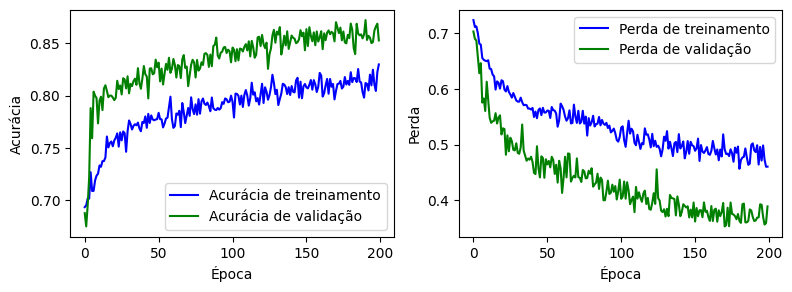

In [17]:
accuracy = model_train.history['binary_accuracy']
val_accuracy = model_train.history['val_binary_accuracy']
loss = model_train.history['loss']
val_loss = model_train.history['val_loss']

#SA_score = model_train.history['SA_score']
#val_SA_score = model_train.history['val_SA_score']

epochs = range(len(accuracy))

array_zeros = np.zeros(len(accuracy)-len(val_accuracy))

# Concatenando os dois arrays
val_accuracy = np.concatenate((val_accuracy, array_zeros))
val_loss = np.concatenate((val_loss, array_zeros))

fig = plt.figure(figsize=(8, 3))

fig.add_subplot(1, 2, 1)
plt.plot(epochs, accuracy, 'b', label='Acurácia de treinamento')
plt.plot(epochs, val_accuracy, 'g', label='Acurácia de validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
fig.tight_layout(pad=1)

fig.add_subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Perda de treinamento')
plt.plot(epochs, val_loss, 'g', label='Perda de validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
fig.tight_layout(pad=1)

#fig.add_subplot(1, 3, 3)
#plt.plot(epochs, SA_score, 'b', label='SA score de treinamento')
#plt.plot(epochs, val_SA_score, 'g', label='SA score de validação')
#plt.title('SA score de treinamento e validação')
#plt.legend()
#fig.tight_layout(pad=1)

plt.savefig(os.path.join(run_dir, "curvas.svg"))
plt.savefig(os.path.join(run_dir, "curvas.png"), dpi=150)

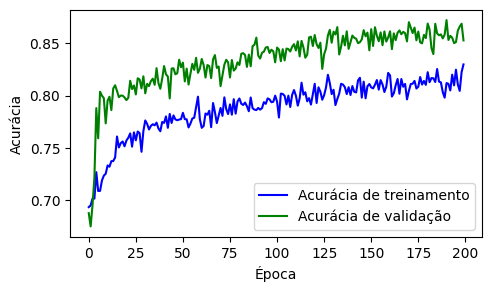

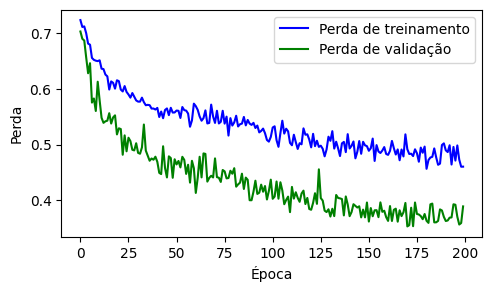

In [18]:
accuracy = model_train.history['binary_accuracy']
val_accuracy = model_train.history['val_binary_accuracy']
loss = model_train.history['loss']
val_loss = model_train.history['val_loss']

#SA_score = model_train.history['SA_score']
#val_SA_score = model_train.history['val_SA_score']

epochs = range(len(accuracy))

array_zeros = np.zeros(len(accuracy)-len(val_accuracy))

# Concatenando os dois arrays
val_accuracy = np.concatenate((val_accuracy, array_zeros))
val_loss = np.concatenate((val_loss, array_zeros))

fig = plt.figure(figsize=(5, 3))

plt.plot(epochs, accuracy, 'b', label='Acurácia de treinamento')
plt.plot(epochs, val_accuracy, 'g', label='Acurácia de validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
fig.tight_layout(pad=1)

plt.savefig(os.path.join(run_dir, "acuracia.svg"))
plt.savefig(os.path.join(run_dir, "acuracia.png"), dpi=150)
plt.show()

fig = plt.figure(figsize=(5, 3))
plt.plot(epochs, loss, 'b', label='Perda de treinamento')
plt.plot(epochs, val_loss, 'g', label='Perda de validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
fig.tight_layout(pad=1)

plt.savefig(os.path.join(run_dir, "perda.svg"))
plt.savefig(os.path.join(run_dir, "perda.png"), dpi=150)
plt.show()

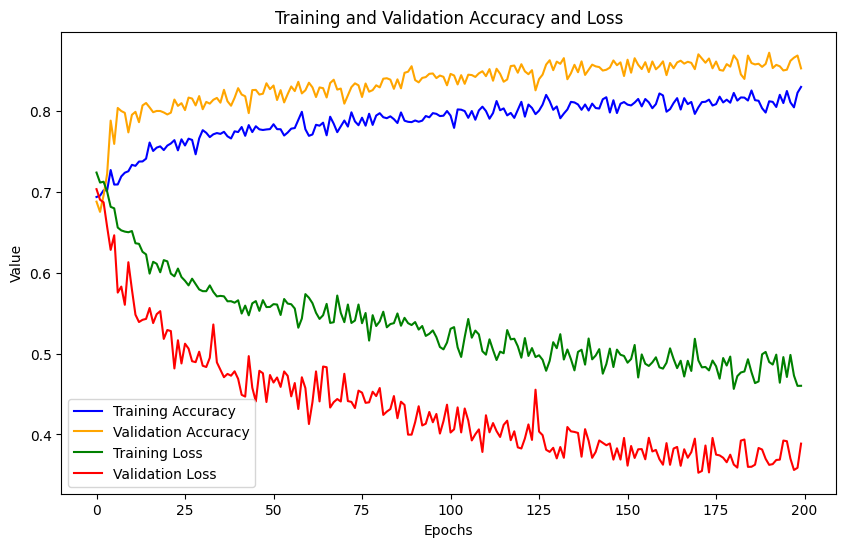

In [19]:
# Plotar métricas: accuracy, val_accuracy, loss, val_loss, mean_iou, val_mean_iou
def plot_history(history):
    acc = history.history['binary_accuracy']
    val_acc = history.history['val_binary_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.figure(figsize=(10, 6))

    plt.plot(epochs, acc, 'b', label='Training Accuracy')
    plt.plot(epochs, val_acc, color='orange', label='Validation Accuracy')
    plt.plot(epochs, loss, 'g', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')

    plt.title('Training and Validation Accuracy and Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Value')
    plt.legend()

    if not os.path.exists(f"saida/imagens"):
      os.mkdir(f"saida/imagens")

    plt.savefig(os.path.join(run_dir, "curvas.svg"))
    plt.savefig(os.path.join(run_dir, "curvas.png"), dpi=150)
    plt.show()


plot_history(model_train)

In [20]:
#model.save(f"saida/modelos_salvos/{modelo}.h5")

#from keras.models import load_model

#model = load_model(f"saida/modelos_salvos/{modelo}.h5",
#                    custom_objects={'mean_iou': mean_iou, 'SA_score': SA_score, 'custom_loss': custom_loss})

In [21]:
print(type(model))
print(model.count_params())

<class 'keras.engine.functional.Functional'>
9231041


In [22]:
x, y= next(test_generator)

masks_teste = model.predict(x)
print("Shape Classes:", masks_teste.shape)

2/2 [==============================] - 15s 5s/step
Shape Classes: (46, 256, 256, 1)


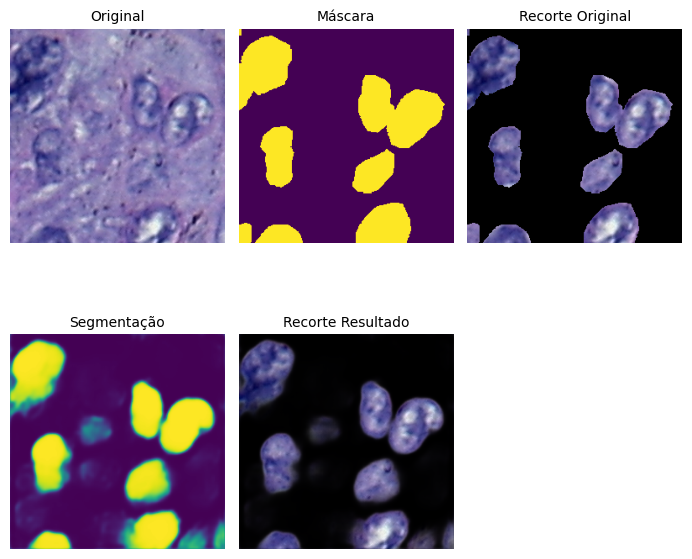

In [23]:
#plt.axis('off')
img = x[0]
msk = y[0].squeeze()
msk = np.stack((msk,)*3, axis=-1)

msk_t = masks_teste[0].squeeze()
msk_t = np.stack((msk_t,)*3, axis=-1)

fig = plt.figure(figsize=(7, 7))

fig.add_subplot(2, 3, 1)
plt.axis('off')
plt.imshow(img)
plt.title('Original', fontsize=10)
fig.tight_layout(pad=1)

fig.add_subplot(2, 3, 2)
plt.axis('off')
plt.imshow(y[0])
plt.title('Máscara', fontsize=10)
fig.tight_layout(pad=1)

fig.add_subplot(2, 3, 3)
plt.axis('off')
plt.imshow(img*msk)
plt.title('Recorte Original', fontsize=10)
fig.tight_layout(pad=1)

fig.add_subplot(2, 3, 4)
plt.axis('off')
plt.imshow(masks_teste[0])
plt.title('Segmentação', fontsize=10)
fig.tight_layout(pad=1)

fig.add_subplot(2, 3, 5)
plt.axis('off')
plt.imshow(img*msk_t)
plt.title('Recorte Resultado', fontsize=10)
fig.tight_layout(pad=1)

fig.savefig(os.path.join(run_dir, "painel_segmentacao.png"), dpi=150, bbox_inches='tight')
fig.savefig(os.path.join(run_dir, "painel_segmentacao.svg"), bbox_inches='tight')

plt.show()

#plt.imshow( np.concatenate([img, msk, img*msk, msk_t, img*msk_t], axis = 1))


In [24]:
def dice_coefficient(true, pred, smooth=1e-6):
    """
    Calcula o coeficiente de Dice.
    Args:
        true: Máscara verdadeira.
        pred: Máscara predita.
        smooth: Valor pequeno para evitar divisão por zero.
    Returns:
        Dice coefficient.
    """
    intersection = np.sum(true * pred)
    union = np.sum(true) + np.sum(pred)
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

In [25]:
def compute_iou(true, pred):
    """
    Computa a Interseção sobre União (IoU) para dois segmentos.
    Args:
        true: Máscara verdadeira.
        pred: Máscara predita.
    Returns:
        IoU: Interseção sobre União.
    """
    intersection = np.logical_and(true, pred)
    union = np.logical_or(true, pred)
    iou = np.sum(intersection) / np.sum(union)
    return iou

def panoptic_quality(true, pred, threshold=0.5):
    """
    Calcula a Panoptic Quality (PQ).
    Args:
        true: Imagem de rótulos verdadeiros.
        pred: Imagem de rótulos preditos.
        threshold: Limiar de IoU para correspondência.
    Returns:
        PQ: Panoptic Quality.
    """
    true_labels = np.unique(true)
    pred_labels = np.unique(pred)

    tp = 0  # True Positives
    fp = 0  # False Positives
    fn = 0  # False Negatives
    sum_iou = 0

    for t in true_labels:
        if t == 0:  # Ignorando o rótulo de fundo
            continue
        matched = False
        for p in pred_labels:
            if p == 0:  # Ignorando o rótulo de fundo
                continue
            iou = compute_iou(true == t, pred == p)
            if iou > threshold:
                tp += 1
                sum_iou += iou
                matched = True
                pred_labels = np.delete(pred_labels, np.where(pred_labels == p))
                break
        if not matched:
            fn += 1

    fp = len(pred_labels) - 1  # Excluindo o fundo

    if tp == 0:
        pq = 0
    else:
        pq = (sum_iou / tp) * (tp / (tp + 0.5 * fp + 0.5 * fn))

    return pq

In [26]:
def jaccard_index(y_true, y_pred, smooth=1e-10):
    """
    Calcula o índice de Jaccard para segmentação de imagens.

    Args:
        y_true: Tensor de rótulos verdadeiros.
        y_pred: Tensor de previsões.
        smooth: Um valor pequeno para evitar divisão por zero.

    Returns:
        Índice de Jaccard.
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(tf.multiply(y_true, y_pred), axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3]) - intersection

    return tf.reduce_mean((intersection + smooth) / (union + smooth)).numpy()

In [27]:
def dice_score(mask_true, mask_pred): ### IMPORTANTE: TESTAR TROCAR A METRICA PRA IOU E ACURÁCIA
    mask_true = tf.cast(mask_true, tf.float32)
    mask_pred = tf.cast(mask_pred, tf.float32)
    intersection = tf.reduce_sum(mask_true * mask_pred)
    dice = (2.0 * intersection) / (tf.reduce_sum(mask_true) + tf.reduce_sum(mask_pred))
    return dice

@keras.saving.register_keras_serializable()
def Mean_SA_score(y_true, y_pred, x_true, useOutput=False): # images, masks, outputs, feature_extractor

    #img = current_X
    img = x_true
    mask = y_true
    #output = current_Y
    output = y_true

    feature_extractor = Model(
       inputs=model.inputs,
       outputs=model.layers[-1].output,
    )

    scores = []

    for i in range(img.shape[0]):
        x = tf.reshape(img[i], (1, img_sz_y, img_sz_x, 3))
        if useOutput: # Calcula a partir do Output ou do Segmentation
          features = y_pred[i]
          x = np.transpose(features, (2, 0, 1)).reshape(1, 1, img_sz_y, img_sz_x)
          #x = np.reshape(features, (1, 1, 256, 256))
        else:
          features = feature_extractor(x)
          x = tf.transpose(features, (0, 3, 1, 2))

        #pred_map = tf.transpose(output[i], (0, 3, 1, 2)) # (32, 256, 256, 1) -> (32, 1, 256, 256)
        #pred_map = tf.reshape(pred_map, (batch_size, 256, 256))

        #x = tf.reshape(img[i], (1, 256, 256, 3))
        #x = tf.reshape(y_pred, (1, 256, 256, 1))
        #features = feature_extractor(x)
        #x = tf.transpose(features, (0, 3, 1, 2))
        #x = tf.transpose(x, (0, 3, 1, 2))

        pred_map = tf.transpose(output[i], (2, 0, 1)) # (256, 256, 1)
        pred_map = tf.reshape(pred_map, (1, 1, img_sz_y, img_sz_x))

        shape = int(x.shape[2])

        # if shape != 256:
        #     x = tf.image.resize(x, size=(img_sz_y, img_sz_x), method='bilinear')

        neters = ProtoSeg(ndims='2d')
        probability_map = neters(x, pred_map, mask=None)
        binary_map = tf.argmax(probability_map, 1)

        bmap = tf.transpose(binary_map, (1, 2, 0))

        #print("binary_map", binary_map.shape)
        #print("bmap", bmap.shape)
        #print("mask", mask[i].shape)

        sa_score = dice_score(mask[i], bmap)

        if np.any(tf.math.is_nan(sa_score)):
            sa_score = 0

        scores.append(float(sa_score))

    return (float(tf.reduce_mean(scores)), float(tf.math.reduce_std(scores))) # (media , desvio padrao)

In [28]:
num_steps = 10
#num_steps = 120
evaluation = model.evaluate(test_generator, steps=num_steps, verbose=-1)

print(modelo)

metricas = [str(x).replace('.', ',') for x in evaluation]
print("Perda:", metricas[0])
print("IOU:", metricas[1])
print("Acurácia:", metricas[2])
print("Precisão:", metricas[3])
print("Recall:", metricas[4])

# print(model.metrics_names)
# print(metricas)

precision = evaluation[3]
recall = evaluation[4]
f1_score = 2 * (precision * recall) / (precision + recall + 1e-7)
f1_score = str(f1_score).replace('.', ',')
print("f1_score:", f1_score)

# y e masks_teste gerados no model.predict
# Convertendo previsões para binárias (ajuste o limiar conforme necessário)
y_pred_bin = (masks_teste > 0.5).astype(np.int32)
y_test_bin = y.astype(np.int32)  # Certifique-se de que y também seja int32
x_test = x

#DICE
# Calculando a métrica Dice para cada imagem no conjunto de teste
dice_scores = [dice_coefficient(true, pred) for true, pred in zip(y_test_bin, y_pred_bin)]
# Média do coeficiente de Dice no conjunto de teste
average_dice = np.mean(dice_scores)
average_dice = str(average_dice).replace('.', ',')
print("Average Dice Coefficient: ", average_dice)

#PQ
# Calculando a métrica Panoptic Quality para cada imagem no conjunto de teste
pq_scores = [panoptic_quality(true, pred) for true, pred in zip(y_test_bin, y_pred_bin)]
# Média da Panoptic Quality no conjunto de teste
average_pq = np.mean(pq_scores)
average_pq = str(average_pq).replace('.', ',')
print("Average Panoptic Quality (PQ): ", average_pq)

#AJI
# Calculando a métrica Aggregate Jaccard Index manualmente
aggregate_jaccard = jaccard_index(y, y_pred_bin)
aggregate_jaccard = str(aggregate_jaccard).replace('.', ',')
print("AJI(Aggregate Jaccard Index):", aggregate_jaccard)

SA_score_mean, SA_score_STD = Mean_SA_score(y_test_bin, y_pred_bin, x_test, useOutput=False)
SA_score_mean = str(SA_score_mean).replace('.', ',')
SA_score_STD = str(SA_score_STD).replace('.', ',')
print("Mean SA Score: ", SA_score_mean)
print("Standard Deviation SA Score: ", SA_score_STD)

SA_score_mean_output, SA_score_STD_output = Mean_SA_score(y_test_bin, y_pred_bin, x_test, useOutput=True)
SA_score_mean_output = str(SA_score_mean_output).replace('.', ',')
SA_score_STD_output = str(SA_score_STD_output).replace('.', ',')
print("Mean SA Score (OUTPUT): ", SA_score_mean_output)
print("Standard Deviation SA Score (OUTPUT): ", SA_score_STD_output)

Unet_crop_OralEpitheliumDB_aug
Perda: 0,44284671545028687
IOU: 0,5849610567092896
Acurácia: 0,8366568088531494
Precisão: 0,6880689859390259
Recall: 0,794674277305603
f1_score: 0,7375392636268139
Average Dice Coefficient:  0,7677502795192968
Average Panoptic Quality (PQ):  0,5669990877791918
AJI(Aggregate Jaccard Index): 0,63195086
Mean SA Score:  0,7491376996040344
Standard Deviation SA Score:  0,09068316221237183
Mean SA Score (OUTPUT):  0,7704376578330994
Standard Deviation SA Score (OUTPUT):  0,08650235831737518


In [29]:
# pesos dentro da pasta da rodada
pesos_path = os.path.join(run_dir, "pesos.weights.h5")
model.save_weights(pesos_path)
print("Pesos salvos:", pesos_path)

# resumo legível da rodada (para bater o olho depois)
import json
resumo = {
    "run_id": run_id,
    "dataset": dataset,
    "protoseg": proto_id,
    "loss": loss_id,
    "seed": SEED,
    "lr": lr,
    "batch_size": batch_size,
    "epochs": len(model_train.history['loss']),
}
with open(os.path.join(run_dir, "config.json"), "w", encoding="utf-8") as f:
    json.dump(resumo, f, indent=2, ensure_ascii=False)
print("Config salva em config.json")

Pesos salvos: saida\runs\Unet__crop_OralEpitheliumDB_aug__proto-offline__loss-focal_dice__seed2024\pesos.weights.h5
Config salva em config.json


In [30]:
import csv, os
from datetime import datetime

registro = {
    "run_id": run_id,
    "loss": loss_id,
    "protoseg": proto_id,
    "seed": SEED,
    "dataset": dataset,
    "perda":    float(evaluation[0]),
    "iou":      float(evaluation[1]),
    "acuracia": float(evaluation[2]),
    "precisao": float(evaluation[3]),
    "recall":   float(evaluation[4]),
    "f1":       float(2*evaluation[3]*evaluation[4]/(evaluation[3]+evaluation[4]+1e-7)),
    "dice":     float(np.mean(dice_scores)),
    "pq":       float(np.mean(pq_scores)),
    "aji":      float(jaccard_index(y, y_pred_bin)),
    "sa_score_mean": float(Mean_SA_score(y_test_bin, y_pred_bin, x_test, useOutput=False)[0]),
    "data_hora": datetime.now().strftime("%Y-%m-%d %H:%M"),
}

arquivo = "resultados_experimentos.csv"
existe = os.path.exists(arquivo)
with open(arquivo, "a", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=list(registro.keys()))
    if not existe:
        w.writeheader()
    w.writerow(registro)
print("Registrado:", run_id)

Registrado: Unet__crop_OralEpitheliumDB_aug__proto-offline__loss-focal_dice__seed2024
